![Imagen](https://docs.google.com/uc?export=download&id=1UteR1e3yMVJsFWAKunJ6_bxfTc5cflv8)



# Google Colab (Colaboratory)  

Google Colab es una plataforma gratuita basada en la nube que permite ejecutar código en **Python** sin necesidad de configuraciones locales. Es especialmente útil para tareas de **aprendizaje automático, ciencia de datos y análisis de datos**.  

##  Características principales  
-  **Ejecutar código en la nube** sin necesidad de instalar nada.  
-  **Acceso gratuito a GPU y TPU** (con limitaciones en la versión gratuita).  
-  **Integración con Google Drive** para guardar y cargar archivos fácilmente.  
-  **Soporte para Jupyter Notebooks** (`.ipynb`).  
-  **Colaboración en tiempo real** (similar a Google Docs).  
-  **Instalación de librerías personalizadas** con `!pip install nombre_librería`.  

##  Casos de uso  
 **Análisis de datos** con **Pandas, NumPy y Matplotlib**.  
 **Entrenamiento de modelos de Machine Learning** con **TensorFlow y PyTorch**.  
 **Procesamiento de imágenes y NLP**.  
 **Ejecutar código pesado sin afectar tu PC**.

In [4]:
#!lscpu  # Información del procesador
#!free -h  # Memoria RAM disponible
#!nvidia-smi  # Si hay GPU, muestra detalles

<h1><font color="#113D68" size=5> Multilayer Perceptron</font></h1>

<h1><font color="#113D68" size=4> Parte 1. Desarrollar una red neuronal</font></h1>

---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Conjunto de datos](#section1)
* [2. Cargar datos](#section2)
* [3. Definir modelo](#section3)
* [4. Compilar modelo](#section4)
* [5. Ajustar modelo](#section5)
* [6. Evaluar modelo](#section6)
* [7. Hacer predicciones](#section7)
* [8. Ejercicio](#section8)


---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

<i class="fa fa-info-circle" aria-hidden="true"></i>
[**Keras** ](https://keras.io/api/)  es una biblioteca de redes neuronales artificiales de código abierto. Está desarrollada en Python y puede ejecutarse sobre diferentes plataformas como TensorFlow o Theano. Keras está diseñado para ir construyendo por bloques la arquitectura de cada red neuronal, incluyendo redes convolucionales y recurrentes, que son las que permiten, junto a los bloques “más tradicionales”, entrenar modelos deep learning.

En esta lección diseñaremos nuestra primera red neuronal.  Los temas son:
* Cargar un conjunto de datos para usar con Keras.
* Diseñar y compilar un modelo de perceptrón multicapa en Keras.
* Evaluar un modelo de Keras.

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Conjunto de datos</font>

En esta lección vamos a utilizar el conjunto de datos Pima Indians Diabetes. Describe los datos de los registros médicos de los pacientes y si tuvieron una aparición de diabetes dentro de los cinco años. Es un problema de clasificación binaria (aparición de diabetes como 1 o 0 si no aparece). Las variables de entrada que describen a cada paciente son numéricas y tienen escalas variables.

Dado que todos los atributos son numéricos, es fácil de usar directamente con redes neuronales que esperan entradas y valores de salida numéricos.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
* Puede descargar el Dataset desde [Kaggle](https://www.kaggle.com/uciml/pima-indians-diabetes-database)

Un valor  de precisión común es del 65% y los mejores resultados en el conjunto de datos están en el rango de 77% de precisión.

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Cargar datos</font>

Vamos a cargar el archivo directamente usando la función `loadtxt()` de NumPy.

In [6]:
# Libreria para cargar nuestro drive
from google.colab import drive
# Cargamos nuestro drive en nuestro notebook
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
#Mostrar el contenido del directorio donde se encuentran los datos
!ls  "/content/drive/MyDrive/Curso_DLCV_2026A/DLCV_11"

Datasets  DLCV_11_Desarrollar_una_red_neuronal.ipynb  DLCV_11_Tarea.ipynb


In [8]:
#Mostrar el contenido del directorio actual
!ls

drive  sample_data


In [10]:
#Cambiando al directorio de trabajo
import os
os.chdir('/content/drive/MyDrive/Curso_DLCV_2026A/DLCV_11')
!ls

Datasets  DLCV_11_Desarrollar_una_red_neuronal.ipynb  DLCV_11_Tarea.ipynb


In [12]:
# Asignando nuestro archivo de datos file_datos
file_datos='Datasets/pima-indians-diabetes.csv'

In [16]:
#Cargamos el dataset
import pandas as pd

df = pd.read_csv(file_datos, header=None)
df.shape


(768, 9)

In [19]:
df.head(5)

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,627.0,50,1
1,1,85,66,29,0,26.6,351.0,31,0
2,8,183,64,0,0,23.3,672.0,32,1
3,1,89,66,23,94,28.1,167.0,21,0
4,0,137,40,35,168,43.1,2288.0,33,1


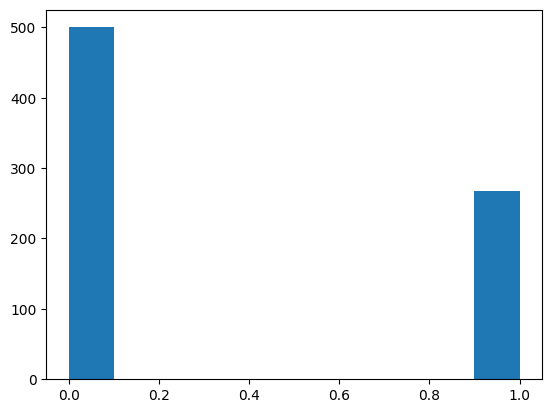

In [15]:

import matplotlib.pyplot as plt

plt.hist( df.iloc[:,-1]  )
plt.show()


In [20]:
# Obtener los datos para X y Y
X = df.loc[:, 0:7]
y = df.loc[:,8]


In [22]:
# X_train, X_test, y_train, y_test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [23]:
# mostrar la cantidad de datos para X_train, X_test, y_train, y_test
print('X_train.shape', X_train.shape)
print('y_train.shape', y_train.shape)
print('X_test.shape', X_test.shape)
print('y_test.shape', y_test.shape)



X_train.shape (614, 8)
y_train.shape (614,)
X_test.shape (154, 8)
y_test.shape (154,)


In [31]:
X_train

,0,1,2,3,4,5,6,7
60,2,84,0,0,0,0.0,304.0,21
618,9,112,82,24,0,28.2,1282.0,50
346,1,139,46,19,83,28.7,654.0,22
294,0,161,50,0,0,21.9,254.0,65
231,6,134,80,37,370,46.2,238.0,46
...,...,...,...,...,...,...,...,...
71,5,139,64,35,140,28.6,411.0,26
106,1,96,122,0,0,22.4,207.0,27
270,10,101,86,37,0,45.6,1136.0,38
435,0,141,0,0,0,42.4,205.0,29


<a id="section3"></a>
# <font color="#004D7F" size=6>3. Definir modelo</font>

Los modelos en Keras se definen como una secuencia de capas. Creamos un modelo **Secuencial** y agregamos capas de una en una hasta que estemos satisfechos con nuestra topología de red.

Lo primero que debe hacer  es asegurarse de que la capa de entrada tenga el número correcto de entradas. Esto se puede especificar al crear la primera capa con el argumento `input_dim` y establecerlo en 8.

Pregunta, **¿Cómo sabemos la cantidad de capas que debemos usar y sus tipos?**


En sí el procedimiento a utilizar será:
1. Las capas completamente conectadas se definen mediante la función `Dense`. Se puede especificar:
    * El número de neuronas en la capa como primer argumento y
    * Especificar la función de activación usando el parámetro `activation`.
2. Usaremos la función de activación ReLu en las dos primeras capas y la función de activación Sigmoidea en la capa de salida.
3. Usamos una función de activación Sigmoid en la capa de salida para garantizar que la salida de nuestra red esté entre 0 y 1.

La siguiente figura proporciona una descripción de la estructura de la red.

<img src="https://docs.google.com/uc?export=download&id=1UyJG8am7xaDcQK1ikePFxNU-Q61lG18r" width="200px" align="center" >  

*Otras funciones de activacion en Keras:*
https://keras.io/api/layers/activations/#available-activations

In [24]:
#Modelo en Keras
from keras.models import Sequential
from keras.layers import Dense, Input

modelo = Sequential()
modelo.add( Input( shape= (8, )) )
modelo.add( Dense(12 , activation='relu' )    )
modelo.add( Dense(8 , activation='relu' )    )
modelo.add( Dense(1 , activation='sigmoid' )    )


<a id="section4"></a>
# <font color="#004D7F" size=6>4. Compilar modelo</font>

Ahora que el modelo está definido, podemos compilarlo.  Al compilar, debemos especificar algunas propiedades adicionales requeridas al entrenar la red.  Debemos especificar:
1. La función de pérdida (loss) mide qué tan equivocado está el modelo durante el entrenamiento.  `binary_crossentropy` se usa cuando el problema es de clasificación binaria, es decir, solo hay dos clases.
2. El optimizador es el algoritmo que actualiza los pesos de la red neuronal para reducir el error.  `adam`  es uno de los optimizadores más usados porque
converge rápido y funciona bien en muchos problemas
3. Las métricas sirven para evaluar el desempeño del modelo, pero no afectan el entrenamiento. `accuracy`  mide la proporción de predicciones correctas con el total de predicciones.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
*Más información sobre el algoritmo de optimización de Adam en el artículo:* [_Adam: A Method for Stochastic Optimization_](https://arxiv.org/abs/1412.6980)

In [29]:
#Compilar el modelo
modelo.compile( loss='binary_crossentropy',
               optimizer='adam',
                metrics=['accuracy'])

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section5"></a>
# <font color="#004D7F" size=6>5. Ajustar modelo</font>

Hemos definido nuestro modelo y lo hemos compilado listo para un cálculo eficiente. Ahora es el momento de ejecutar el modelo en algunos datos llamando a la función `fit()`.
* El proceso de entrenamiento se ejecutará para un número fijo de iteraciones usando el argumento `epochs`.
* También podemos establecer el número de instancias que se evalúan antes de que se realice una actualización de peso en la red, denominada tamaño de batch, y se establece mediante el argumento `batch_size` (subconjunto de datos durante una iteración)

In [30]:
# Fit del modelo
modelo.fit(X_train, y_train, epochs=20 , batch_size=30)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5803 - loss: 4.1234
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4959 - loss: 1.7268
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5520 - loss: 1.0567 
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5868 - loss: 0.9897 
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5830 - loss: 0.8413 
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5772 - loss: 0.7806 
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6008 - loss: 0.7461 
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5800 - loss: 0.7610 
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6026 - loss: 0.6747 
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6090 - loss: 0.6599 
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5867 - loss: 0.6987 
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section6"></a>
# <font color="#004D7F" size=6>6. Evaluar el modelo</font>

Podemos evaluar el modelo en el conjunto de datos de entrenamiento usando la función de `evaluation()` y pasar la misma entrada y salida que usaste para entrenar el modelo.

In [33]:
#Evaluación del modelo
modelo.evaluate(X_test,y_test)[1]


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7233 - loss: 0.8406 


0.7077922224998474

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section7"></a>
# <font color="#004D7F" size=6>7. Hacer predicciones</font>

Podemos llamar a la función `predict()` para predecir clases directamente, por ejemplo:

In [ ]:
# Prediccion



Veamos un ejemplo en las primeras *n* entradas

<a id="section8"></a>
# <font color="#004D7F" size=6> Ejercicio 1 </font>



```html
Realizar modificaciones para intentar mejorar la precisión.

```